## Section 1: Imports & Sample DataFrame

In [14]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
# This tells Jupyter Notebook to show the charts directly under the code cell.
%matplotlib inline

# This creates the sales table. The variable df_sales stores the whole table.
df_sales = pd.DataFrame({
    'region': ['North', 'South', 'East', 'West', 'Central'],
    'jan': [12400, 9800, 15200, 8700, 11300],
    'feb': [13100, 10500, 14800, 9200, 12100],
    'mar': [14500, 11200, 16300, 10100, 13400],
    'apr': [13800, 10900, 15700, 9600, 12800],
    'may': [15200, 11800, 17100, 10400, 14200],
    'jun': [16000, 12400, 18500, 11000, 15600]
})

# This list stores the month column names so it doesn't have to be typed in again and again.
months_cols = ['jan', 'feb', 'mar', 'apr', 'may', 'jun']

# This creates a new column called total_sales.
# df_sales[months_cols] selects only the month columns.
# .sum(axis=1) adds across each row, so it adds Jan through Jun for each region.
df_sales['total_sales'] = df_sales[months_cols].sum(axis=1)

print(df_sales)

    region    jan    feb    mar    apr    may    jun  total_sales
0    North  12400  13100  14500  13800  15200  16000        85000
1    South   9800  10500  11200  10900  11800  12400        66600
2     East  15200  14800  16300  15700  17100  18500        97600
3     West   8700   9200  10100   9600  10400  11000        59000
4  Central  11300  12100  13400  12800  14200  15600        79400


## Section 2: Single Line Chart

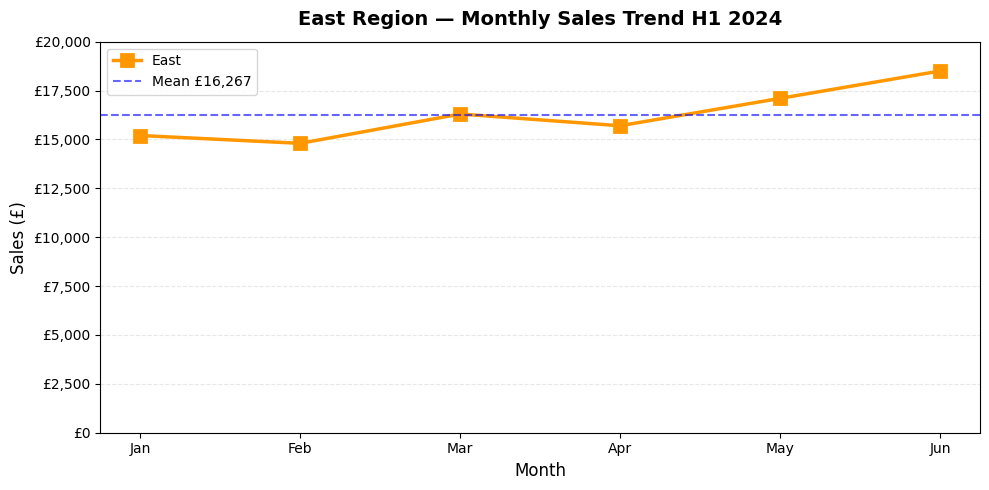

In [15]:
# months stores a list that will act as a container for the x-axis values.
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']

# Filtered for only the East row, grabbed its month values, and turned them into a list so Matplotlib can graph it.
east = df_sales.loc[df_sales['region'] == 'East', months_cols].values[0].tolist()

# This creates the chart canvas, ax is short for axes, where the chart will be drawn, and figsize is where the size is assigned.
fig, ax = plt.subplots(figsize=(10, 5))

# This starts drawing the line chart.
# Everything inside the parentheses is the instructions for how the line should look.
ax.plot(
    months, # this will become the x-axis data
    east,   # this is the y-axis data
    color='#FF9800', # hex color code to change the color
    linewidth=2.5,   # controls the line thickness
    marker='s',   # square marker
    markersize=8, # this controls the marker size
    markerfacecolor='#FF9800',  # this fills the color inside the square
    markeredgewidth=2,  # this controls the border thickness of the square
    linestyle='-',  # this controls the line style, this specific one is for solid line
    label='East'    # this will create the legend name
)

ax.set_title('East Region — Monthly Sales Trend H1 2024', # this adds the chart title and formatting
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Month', fontsize=12)      # this adds a label to the x-axis (horizontal axis) and sets the font size
ax.set_ylabel('Sales (£)', fontsize=12)  # this adds a label to the y-axis (vertical axis) and sets the font size

# This line starts formatting the numbers on the y-axis.
# Creating a custom formatting rule for how the numbers should be displayed
# Using lambda to format every number
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)

# Calculating the average monthly sales.
mean_val = sum(east) / len(east)

# Drawing a horizontal line.
ax.axhline(
    mean_val,  # this tells Python to put the line at the average value
    color='blue', # formats the color to blue per exercise
    linestyle='--', # dashed lines
    alpha=0.6,  # this controls the transparency
    label=f'Mean £{mean_val:,.0f}' # this creates a legend label
)

ax.grid(axis='y', alpha=0.3, linestyle='--') # this adds background guide lines horizontally, light/faint and using dashed gridlines
ax.set_ylim(0, 20000)  # Sets min and max y-axis values
ax.legend(fontsize=10) # this creates a legend box

plt.tight_layout() # this fixes spacing
plt.show() # displays chart

## Section 3: Multi-Line Chart

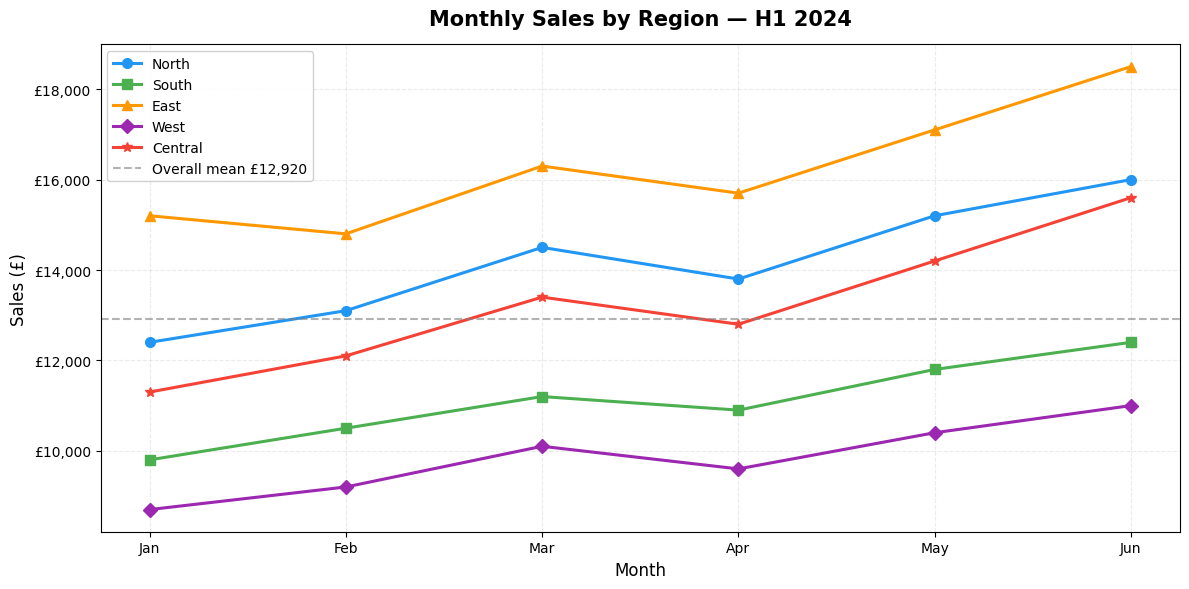

In [16]:
# Stores the month names for the x-axis.
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']

# Sstores 5 colors because df_sales has 5 regions.
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']

# Stores 5 marker shapes because each region needs its own marker.
markers = ['o', 's', '^', 'D', '*']

# Creates the chart canvas. fig is the whole figure, and ax is the actual graph area.
fig, ax = plt.subplots(figsize=(12, 6))

# loops through each region row one at a time. i stores the row number, and row stores the current region’s data.
for i, row in df_sales.iterrows():
    ax.plot(    # draws one line per region and since the loop runs 5 times, it draws 5 lines
        months, # gives the x-axis values
        row[months_cols], # gives the y-axis values for that current region from January to June
        color=colors[i], # chooses a color based on the row number
        marker=markers[i], # chooses a marker shape based on the row number
        linewidth=2.2,  
        markersize=7,
        label=row['region']  # uses the region name in the legend
    )

# Calculate the average of all monthly sales values.
overall_mean = df_sales[months_cols].values.mean()

# Add a horizontal dashed line for the overall mean.
ax.axhline(
    overall_mean,
    color='gray',
    linestyle='--',
    alpha=0.6,
    linewidth=1.5,
    label=f'Overall mean £{overall_mean:,.0f}'
)

# Add chart title and axis labels.
ax.set_title('Monthly Sales by Region — H1 2024',
             fontsize=15, fontweight='bold', pad=14)
# Labels the x-axis as Month.
ax.set_xlabel('Month', fontsize=12)
# Labels the y-axis as Sales.
ax.set_ylabel('Sales (£)', fontsize=12)

# Format the y-axis as currency.
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)

# Add legend and grid.
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax.grid(alpha=0.25, linestyle='--')

# Display the chart neatly.
plt.tight_layout()
plt.show()

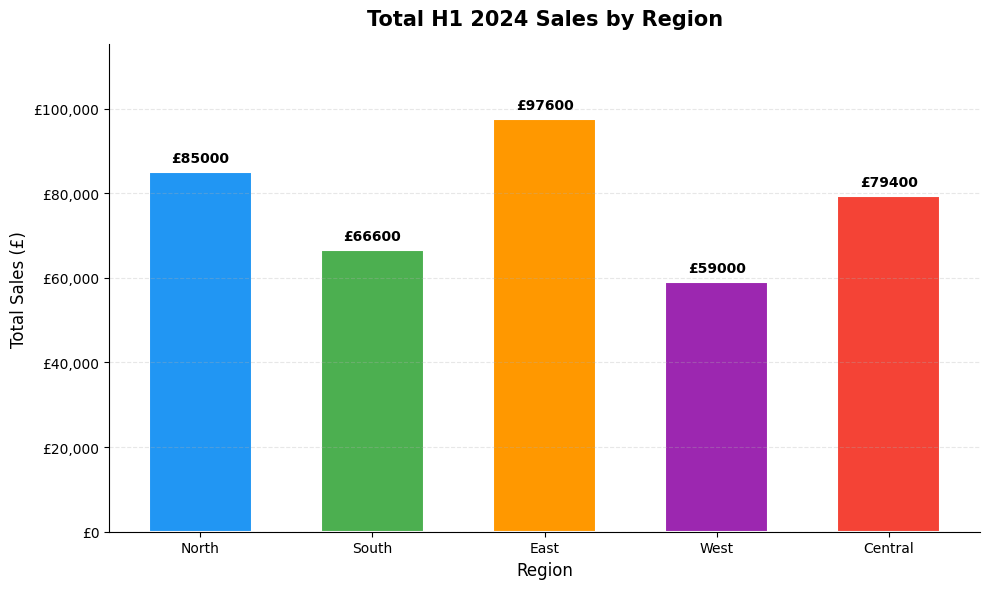

In [18]:
# This creates one color for each region.
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']

# fig creates the canvas. ax is the actual graph area where bars are drawn
fig, ax = plt.subplots(figsize=(10, 6))

# Creating the bars.
bars = ax.bar(
    df_sales['region'],      # x-axis category labels
    df_sales['total_sales'], # y-axis values (bar height)
    color=colors, # assigns colors
    width=0.6,  # controls the bar thickness
    edgecolor='white',  # adds white as the border around each bar
    linewidth=1.5  # controls the border thickness
)

# Add value labels above each bar.
ax.bar_label(
    bars,
    fmt='£%.0f',  # formats labels as money
    padding=5,   # adds spacing above the bar
    fontsize=10, # controls text size
    fontweight='bold' # makes labels bold
)

# Add chart title and axis labels.
ax.set_title(
    'Total H1 2024 Sales by Region',
    fontsize=15,   # controls text size
    fontweight='bold', # makes labels bold
    pad=14  # # adds spacing
)

# Labels the x axis
ax.set_xlabel('Region', fontsize=12)
#Labels the y axis
ax.set_ylabel('Total Sales (£)', fontsize=12)

# Format y-axis as currency.
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}')
)

# Sets chart limit so labels do not get cut off.
# max() is finding the tallest bar and adding extra space above.
ax.set_ylim(0, df_sales['total_sales'].max() * 1.18)

# Add gridlines to help compare bar heights
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Hide top and right chart borders to get a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust spacing and show chart.
plt.tight_layout()
plt.show()